In [89]:
import pandas as pd
import folium
from folium.plugins import HeatMap 
import missingno as msno
import matplotlib.pyplot as plt 
import seaborn as sns

# Inizializing the data

In [90]:
# Load the data
file_path_accidents = "Accident data/Accident data/Ongevallengegevens/ongevallen.txt" 
file_path_locations = "Accident data/Accident data/Netwerkgegevens/puntlocaties.txt"

df_accidents = pd.read_csv(file_path_accidents, delimiter=',') 
df_locations = pd.read_csv(file_path_locations, delimiter=',')

df_accidents.head(), df_locations.head() 

C:\Users\KeesK\AppData\Local\Temp\ipykernel_27456\2554765293.py:5: DtypeWarning: Columns (1,2,24,25,29,31,35,39,43,47,52,64) have mixed types. Specify dtype option on import or set low_memory=False.
  df_accidents = pd.read_csv(file_path_accidents, delimiter=',')


(    VKL_NUMMER     REGNUMMER PVOPGEM  DATUM_VKL  DAG_CODE  MND_NUMMER  \
 0  20140135691  2014121457.0       J        NaN       NaN         NaN   
 1  20140135692  2014273612.0     NaN        NaN       NaN         NaN   
 2  20140135693  2014095971.0     NaN        NaN       NaN         NaN   
 3  20140135694  2014081170.0     NaN        NaN       NaN         NaN   
 4  20140135695  2014218979.0     NaN        NaN       NaN         NaN   
 
    JAAR_VKL  TIJDSTIP  UUR  DDL_ID  ...      PVE_NAAM  \
 0      2014       NaN  NaN     NaN  ...  Zuid-Holland   
 1      2014       NaN  NaN     NaN  ...  Zuid-Holland   
 2      2014       NaN  NaN     NaN  ...  Zuid-Holland   
 3      2014       NaN  NaN     NaN  ...  Zuid-Holland   
 4      2014       NaN  NaN     NaN  ...  Zuid-Holland   
 
                                    KDD_NAAM  \
 0  REGIO ZUID HOLLAND-OV                      
 1  REGIO ZUID HOLLAND-OV                      
 2  STADSGEWEST HAAGLANDEN                     
 3  STADSGEW

# Data cleaning

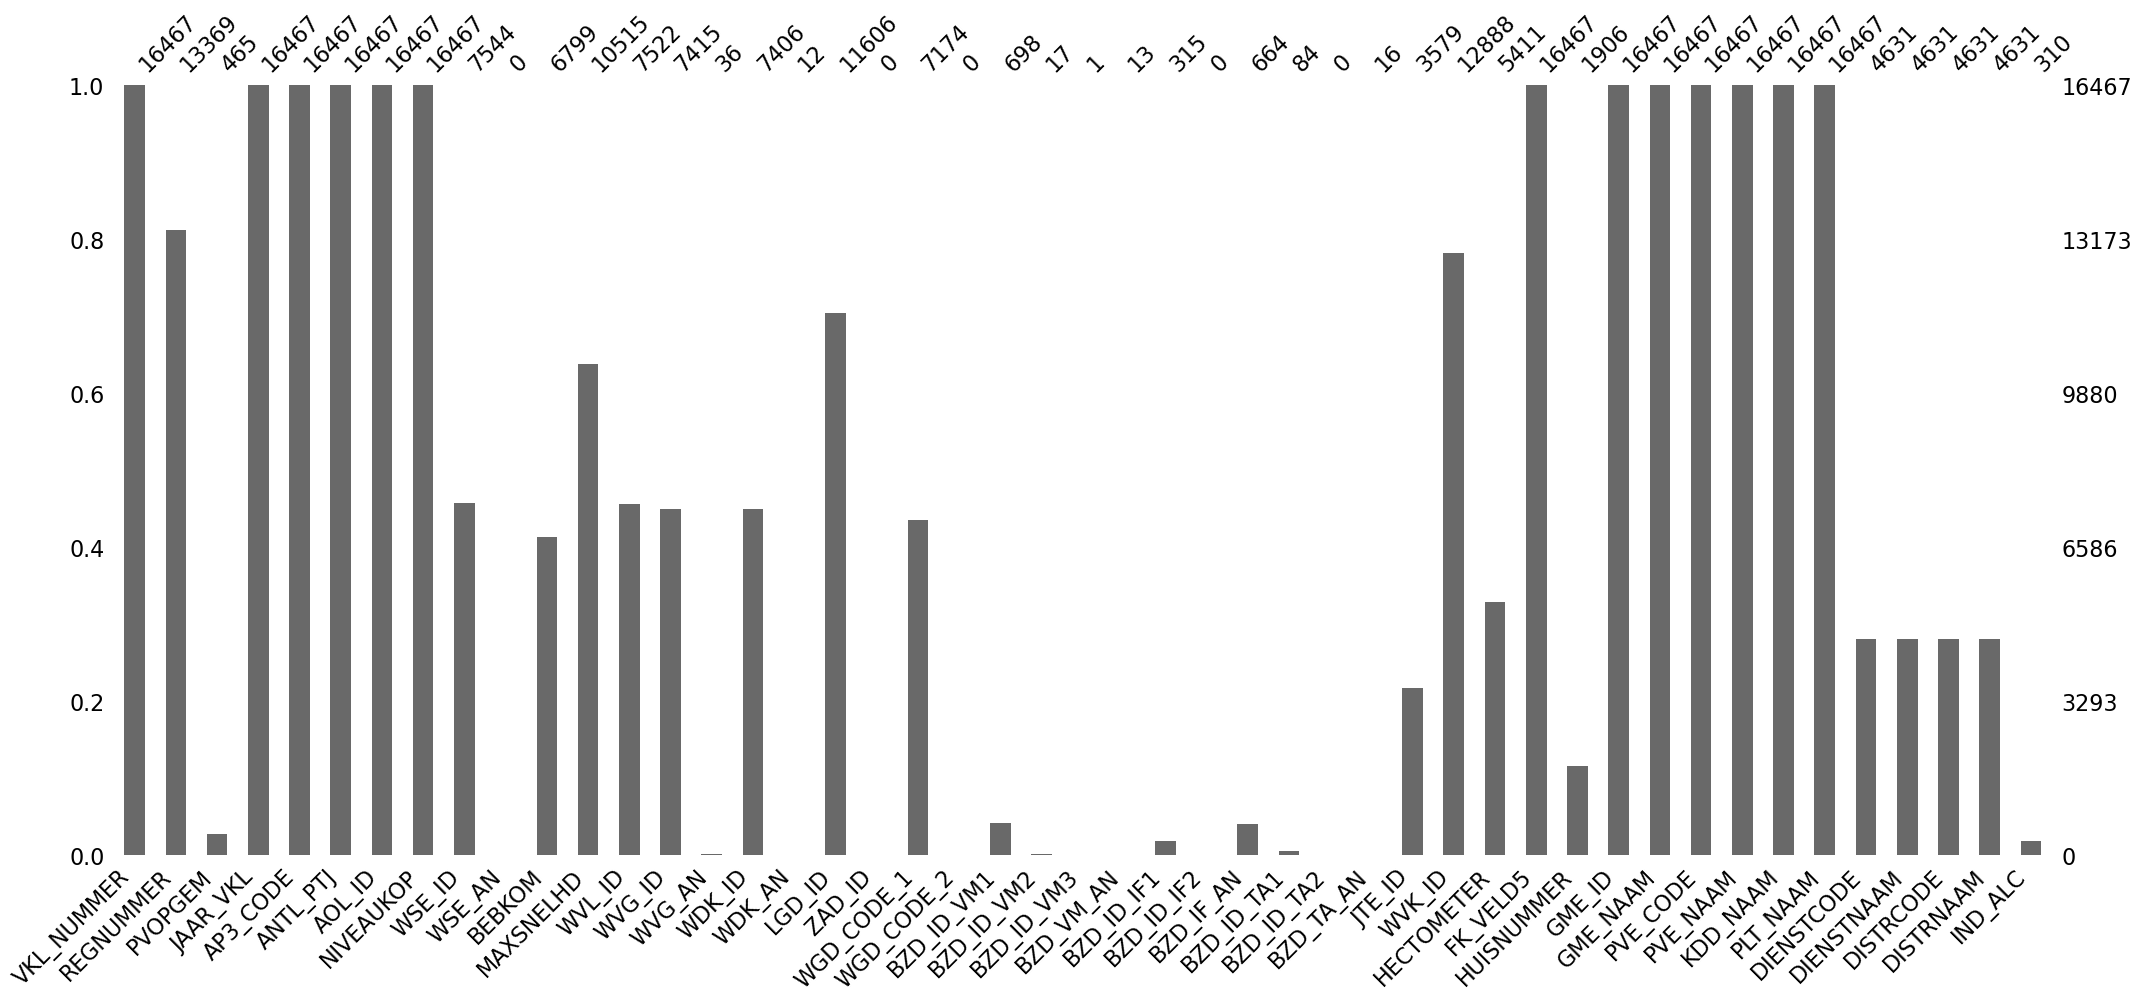

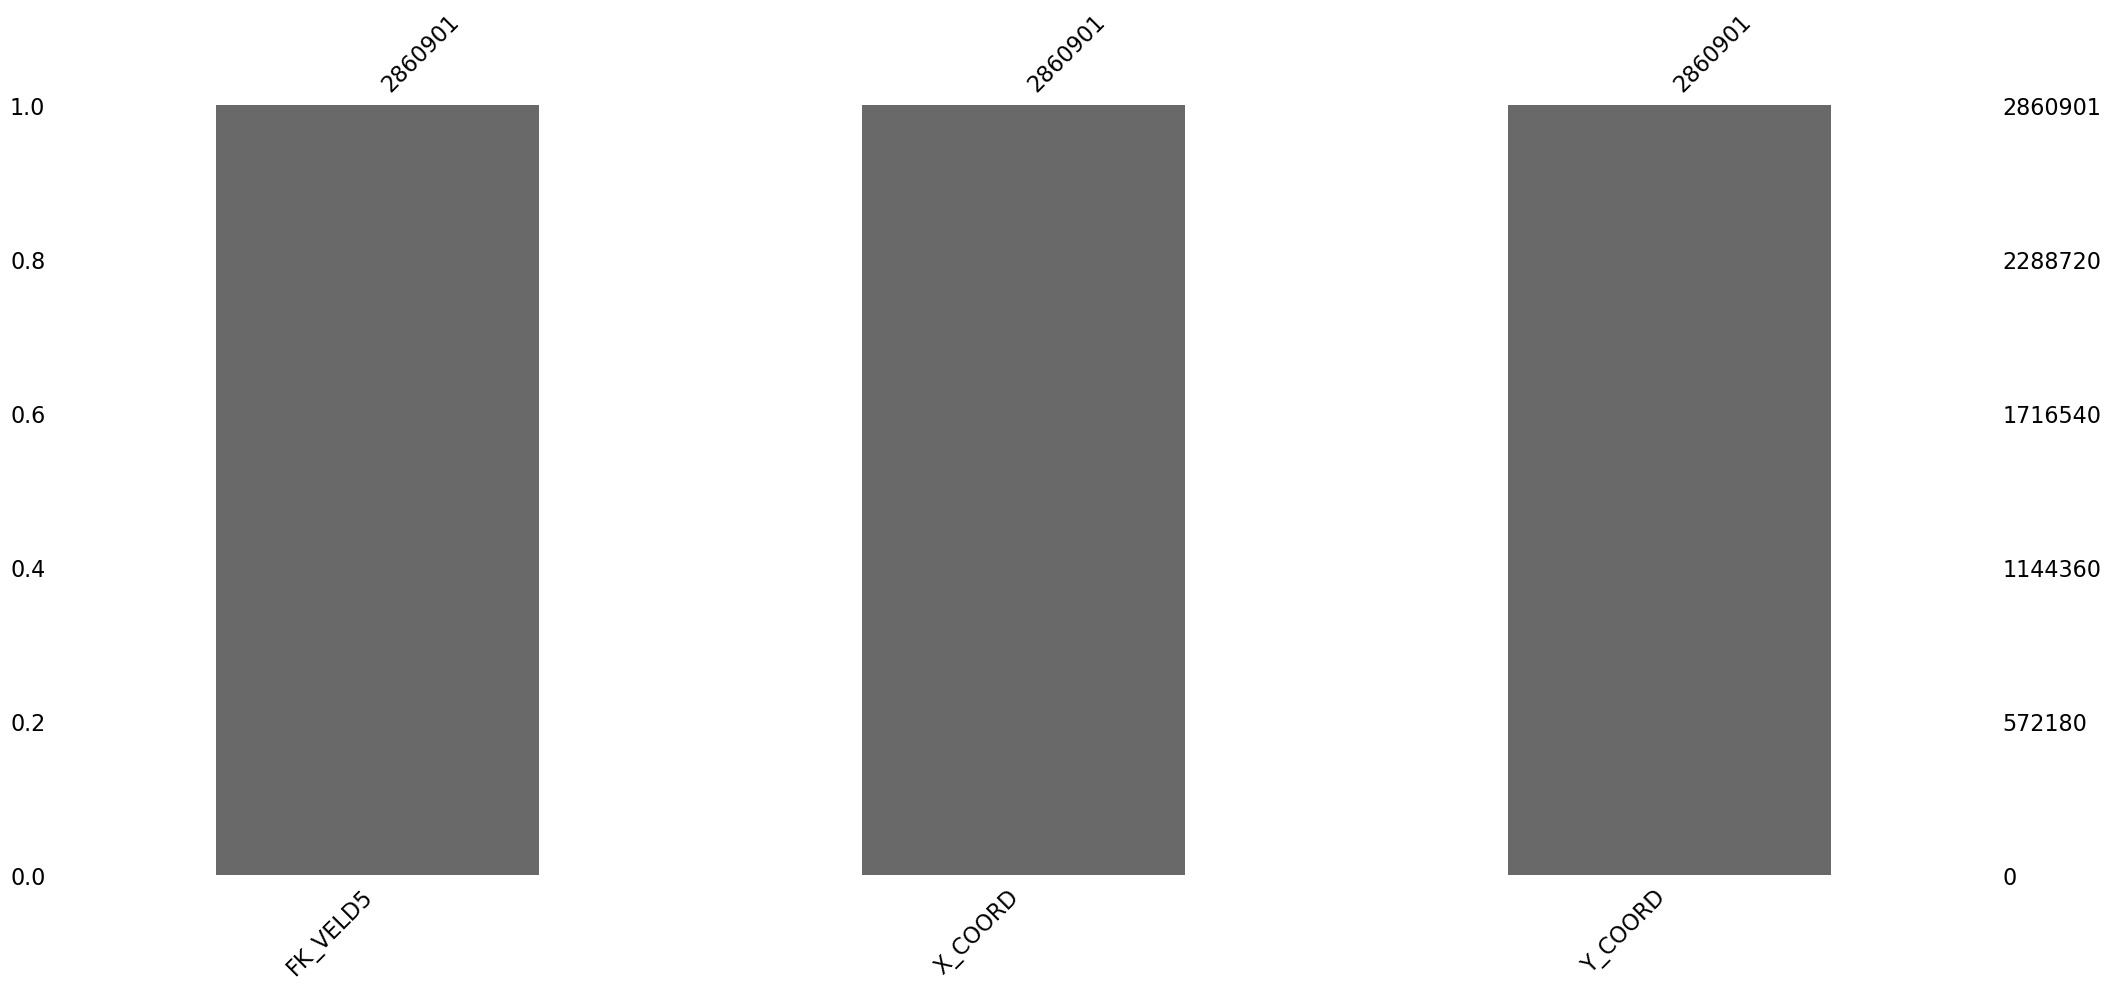

In [91]:
import missingno as msno
import matplotlib.pyplot as plt

df_accidents = df_accidents.dropna(axis=1, how='all') 
df_locations = df_locations.dropna(axis=1, how='all') 

df_accidents = df_accidents[df_accidents['GME_NAAM'] == 'Breda']  

msno.bar(df_accidents)
plt.show() 

msno.bar(df_locations)
plt.show()



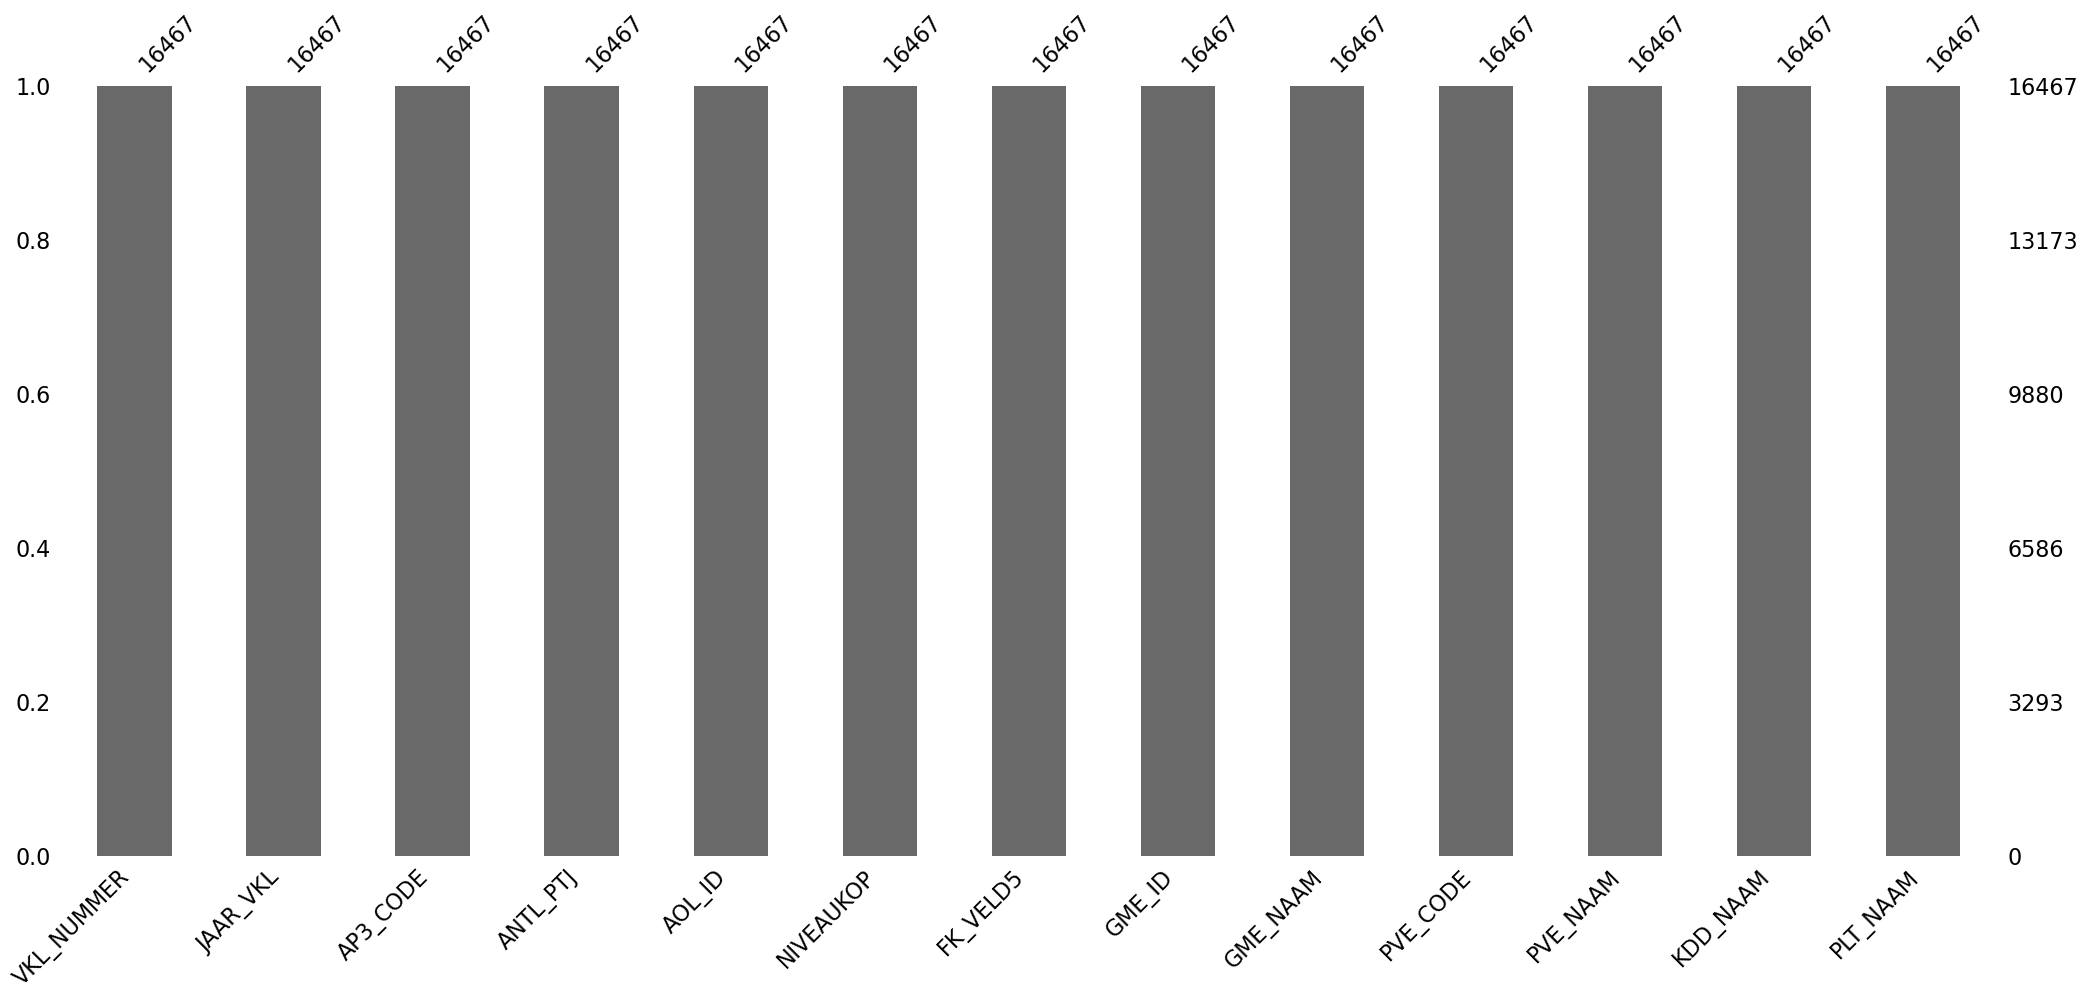

,VKL_NUMMER,JAAR_VKL,AP3_CODE,ANTL_PTJ,AOL_ID,NIVEAUKOP,FK_VELD5,GME_ID,GME_NAAM,PVE_CODE,PVE_NAAM,KDD_NAAM,PLT_NAAM
364,20140141297,2014,UMS,1,9,G,JTE0223195056,758,Breda,NB,Noord-Brabant,REGIO NOORD BRABANT-OV,Regionale Eenheid Zeeland - West-Brabant
365,20140141298,2014,UMS,2,0,E,HTT02142110100559,758,Breda,NB,Noord-Brabant,REGIO NOORD BRABANT-OV,Regionale Eenheid Zeeland - West-Brabant
369,20140141302,2014,UMS,2,0,S,WVK0221202005,758,Breda,NB,Noord-Brabant,REGIO NOORD BRABANT-OV,Regionale Eenheid Zeeland - West-Brabant
371,20140141304,2014,UMS,2,0,E,WVK0225198149,758,Breda,NB,Noord-Brabant,REGIO NOORD BRABANT-OV,Regionale Eenheid Zeeland - West-Brabant
372,20140141305,2014,LET,3,0,G,JTE0228205006,758,Breda,NB,Noord-Brabant,REGIO NOORD BRABANT-OV,Regionale Eenheid Zeeland - West-Brabant


In [92]:
df_accidents = df_accidents.dropna(axis=1) 

msno.bar(df_accidents)
plt.show() 

df_accidents.head()

# Merging the dataframes

In [93]:
df_accidents = df_accidents.drop(['AOL_ID',	'NIVEAUKOP','GME_ID', 'GME_NAAM', 'PVE_CODE', 'PVE_NAAM', 'KDD_NAAM', 'PLT_NAAM'], axis=1) 
df_accidents.head()

,VKL_NUMMER,JAAR_VKL,AP3_CODE,ANTL_PTJ,FK_VELD5
364,20140141297,2014,UMS,1,JTE0223195056
365,20140141298,2014,UMS,2,HTT02142110100559
369,20140141302,2014,UMS,2,WVK0221202005
371,20140141304,2014,UMS,2,WVK0225198149
372,20140141305,2014,LET,3,JTE0228205006


In [94]:
df_combined = pd.merge(df_accidents, df_locations, on='FK_VELD5', how='left')  

df_combined.head() 

,VKL_NUMMER,JAAR_VKL,AP3_CODE,ANTL_PTJ,FK_VELD5,X_COORD,Y_COORD
0,20140141297,2014,UMS,1,JTE0223195056,111849.045,397964.775
1,20140141298,2014,UMS,2,HTT02142110100559,107749.650,404526.089
2,20140141302,2014,UMS,2,WVK0221202005,110749.487,401441.081
3,20140141304,2014,UMS,2,WVK0225198149,112728.055,399420.429
4,20140141305,2014,LET,3,JTE0228205006,114324.755,402854.042


# Mutating the RD coordinates to GPS coordinates 

In [95]:
from pyproj import Transformer

# Initialize the transformer: RD (EPSG:28992) to WGS84 (EPSG:4326)
transformer = Transformer.from_crs("EPSG:28992", "EPSG:4326") 

# Function to transform RD to WGS84
def transform_rd_to_wgs84(x, y):
    return transformer.transform(x, y) 

# Apply the transformation to the DataFrame
df_combined[['Latitude', 'Longitude']] = df_combined.apply(
    lambda row: transform_rd_to_wgs84(row['X_COORD'], row['Y_COORD']), axis=1, result_type='expand'
) 

#Drop the columns that are not needed anymore
df_combined = df_combined.drop(['X_COORD', 'Y_COORD'], axis=1)

df_combined.head()  

,VKL_NUMMER,JAAR_VKL,AP3_CODE,ANTL_PTJ,FK_VELD5,Latitude,Longitude
0,20140141297,2014,UMS,1,JTE0223195056,51.568960,4.764808
1,20140141298,2014,UMS,2,HTT02142110100559,51.627604,4.704797
2,20140141302,2014,UMS,2,WVK0221202005,51.600120,4.748510
3,20140141304,2014,UMS,2,WVK0225198149,51.582111,4.777310
4,20140141305,2014,LET,3,JTE0228205006,51.613091,4.799947


# Removing missing values in ANTL_PTJ

In [96]:
x = df_combined['ANTL_PTJ'].value_counts() 
x


ANTL_PTJ
2     6445
0     6009
1     2500
3     1147
4      256
5       77
6       16
7        7
8        5
9        2
10       1
11       1
13       1
Name: count, dtype: int64

In [97]:
df_combined = df_combined[df_combined['ANTL_PTJ'] != 0] 

x = df_combined['ANTL_PTJ'].value_counts() 
x

ANTL_PTJ
2     6445
1     2500
3     1147
4      256
5       77
6       16
7        7
8        5
9        2
10       1
11       1
13       1
Name: count, dtype: int64

# Renaming columns and valuables to English for Interpretability 

In [98]:
x = df_combined['AP3_CODE'].value_counts() 
x 

AP3_CODE
UMS    8866
LET    1532
DOD      60
Name: count, dtype: int64

In [99]:
def rename_accident_severity(code):
    code = code.strip().upper()  
    if code == "UMS":
        return 'Vehicle Damage'
    elif code == "LET":
        return 'Wounded'
    elif code == "DOD":  
        return 'Fatal'
    else:
        return 'Unknown'  

df_combined['AP3_CODE'] = df_combined['AP3_CODE'].apply(rename_accident_severity)

x = df_combined['AP3_CODE'].value_counts()
x

AP3_CODE
Vehicle Damage    8866
Wounded           1532
Fatal               60
Name: count, dtype: int64

In [100]:
df_combined = df_combined.rename(columns={'JAAR_VKL': 'Year', 'AP3_CODE': 'Accident_Severity', 'ANTL_PTJ': 'Parties_Involved','FK_VELD5': 'Area_Code'}) 
df_combined




,VKL_NUMMER,Year,Accident_Severity,Parties_Involved,Area_Code,Latitude,Longitude
0,20140141297,2014,Vehicle Damage,1,JTE0223195056,51.568960,4.764808
1,20140141298,2014,Vehicle Damage,2,HTT02142110100559,51.627604,4.704797
2,20140141302,2014,Vehicle Damage,2,WVK0221202005,51.600120,4.748510
3,20140141304,2014,Vehicle Damage,2,WVK0225198149,51.582111,4.777310
4,20140141305,2014,Wounded,3,JTE0228205006,51.613091,4.799947
...,...,...,...,...,...,...,...
16112,20220256733,2022,Vehicle Damage,1,WVK0600123027,51.566457,4.821097
16113,20220262161,2022,Vehicle Damage,1,WVK0231192007,51.565931,4.821175
16114,20220264884,2022,Vehicle Damage,2,HTT06001220190630,51.529733,4.743601
16115,20220267225,2022,Vehicle Damage,1,WVK0231192010,51.550348,4.832883


# Making a heatmap and saving dataframe to a CSV file 

In [101]:
import folium
from folium.plugins import HeatMap

# Initialize the map
mymap = folium.Map(location=[51.5, 4.5], zoom_start=10)

# Create a heatmap layer using the latitude and longitude columns from df_combined
locations = df_combined[['Latitude', 'Longitude']].values.tolist()

# Create a heatmap layer
HeatMap(locations).add_to(mymap)

# Save the map to an HTML file
mymap.save('heatmap_all_locations.html')


In [102]:
filtered_df = df_combined[df_combined['Area_Code'].str.startswith('JTE')]
filtered_df 

# Initialize the map
mymap2 = folium.Map(location=[51.5, 4.5], zoom_start=10)

# Create a heatmap layer using the latitude and longitude columns from df_combined
locations = filtered_df[['Latitude', 'Longitude']].values.tolist()

# Create a heatmap layer
HeatMap(locations).add_to(mymap2)

# Save the map to an HTML file
mymap2.save('heatmap_junctions.html')

In [103]:
df_combined.to_csv('accidents_data_breda_2013-2022.csv', index=False)